['7', '2', '3', '6', '4', '11', '5', '1', '10', '9', '8']
Processing image: 7.png


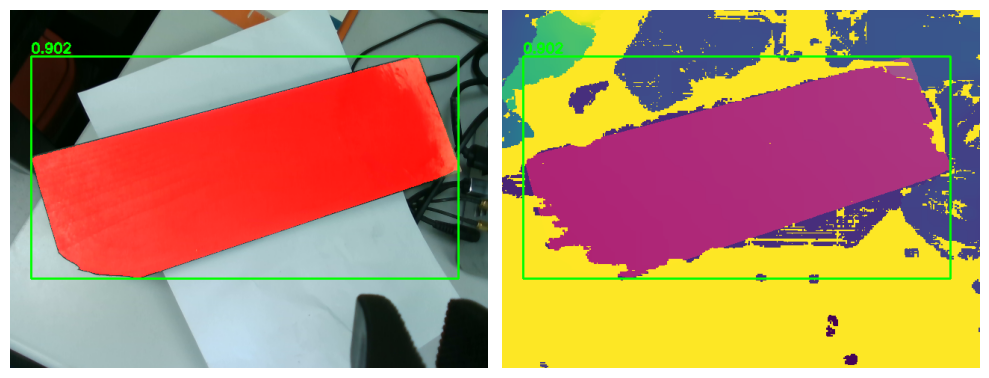

最近点深度： 0.299
单帧原始点云数量: 91720 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======>                                ] 17%
 单帧过滤后点云数量: 30138
(4, 4) (4, 30138)l outliers: [=======================================>] 97%
Processing image: 2.png


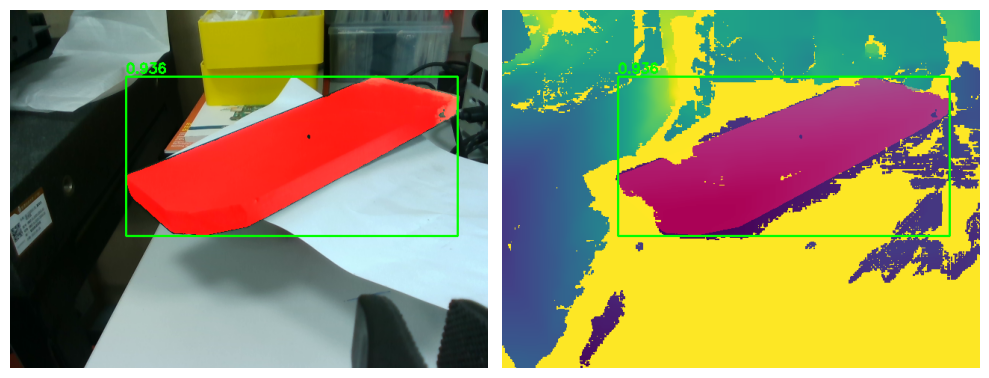

最近点深度： 0.314
单帧原始点云数量: 42606 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [============>                           ] 30%
 单帧过滤后点云数量: 23790
(4, 4) (4, 23790)l outliers: [=======================================>] 97%
Processing image: 3.png


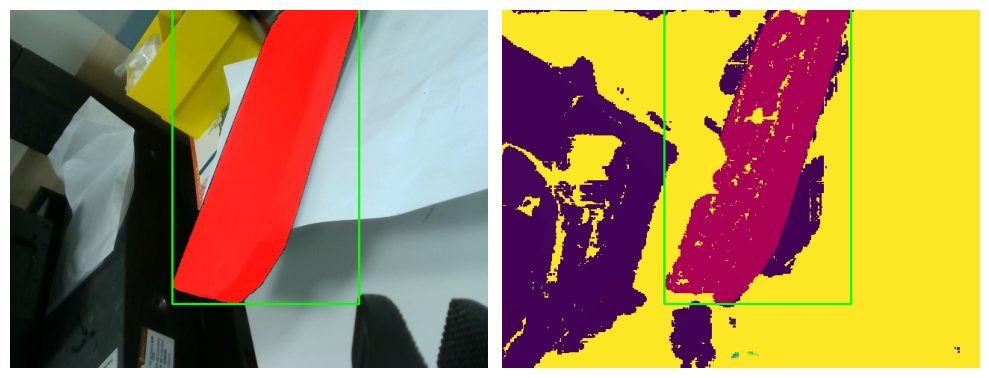

最近点深度： 0.302
单帧原始点云数量: 43131 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 20690
(4, 4) (4, 20690)
Processing image: 6.png


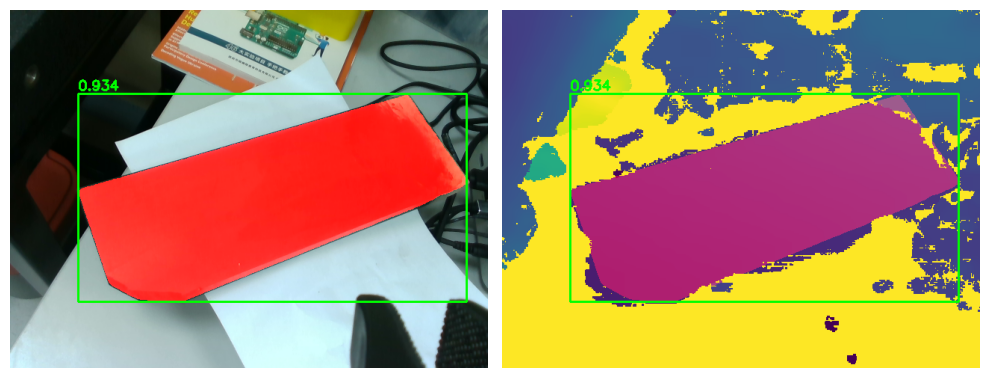

最近点深度： 0.217
单帧原始点云数量: 77361 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [==>                                     ] 5%
 单帧过滤后点云数量: 33258
(4, 4) (4, 33258)l outliers: [=======================================>] 97%
Processing image: 4.png


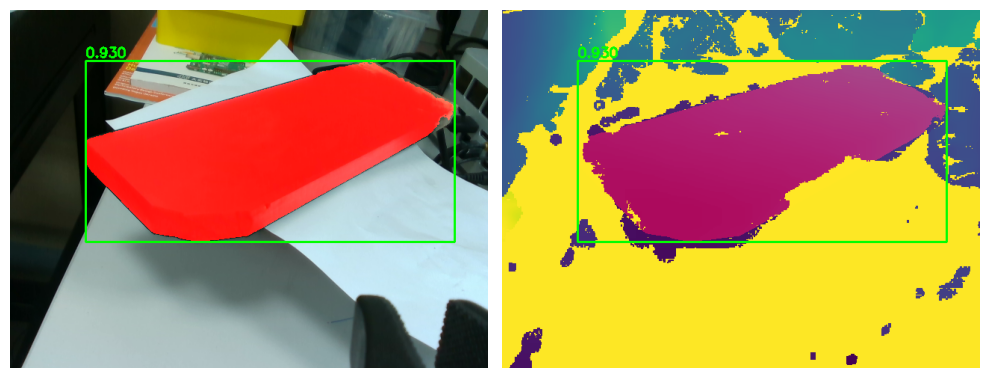

最近点深度： 0.238
单帧原始点云数量: 63067 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [======>                                 ] 15%
 单帧过滤后点云数量: 28305
(4, 4) (4, 28305)l outliers: [=======================================>] 97%
Processing image: 11.png


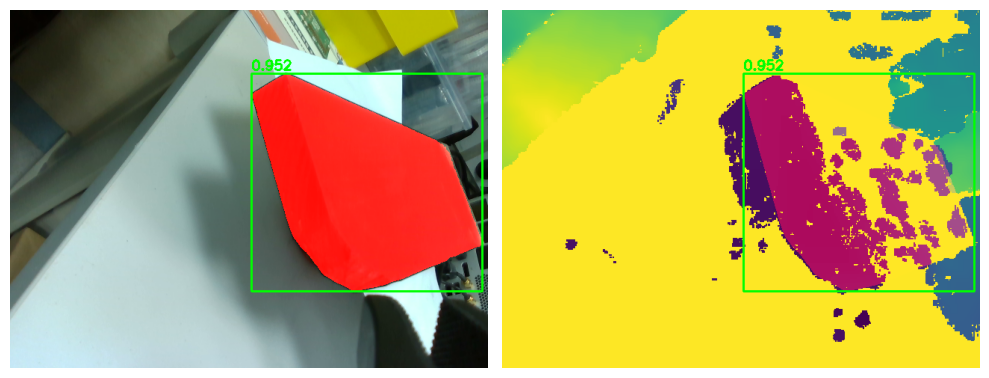

最近点深度： 0.189
单帧原始点云数量: 33949 
 

 单帧过滤后点云数量: 8514
Remove statistical outliers: [========================================] 100%
(4, 4) (4, 8514)al outliers: [=======================================>] 97%
Processing image: 5.png


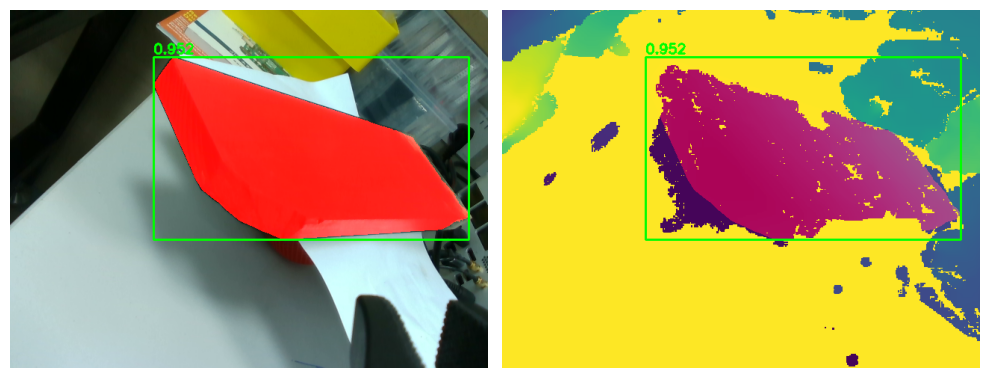

最近点深度： 0.213
单帧原始点云数量: 52738 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 23890
(4, 4) (4, 23890)
Processing image: 1.png


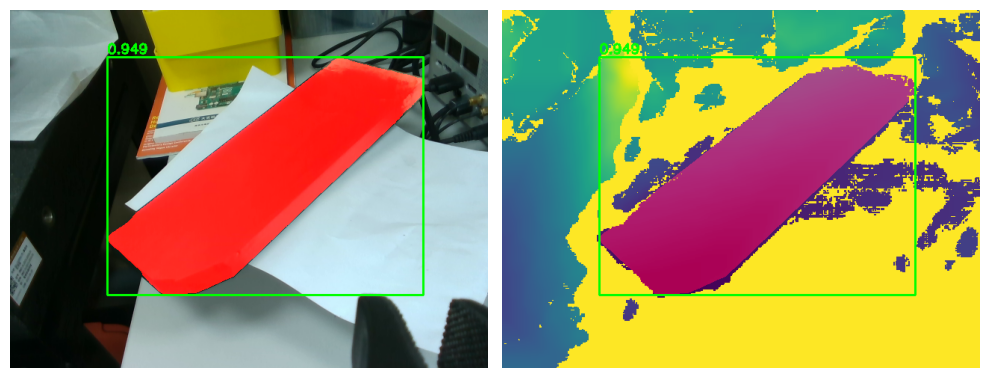

最近点深度： 0.323
单帧原始点云数量: 54694 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [========>                               ] 20%
 单帧过滤后点云数量: 29887
(4, 4) (4, 29887)l outliers: [=======================================>] 97%
Processing image: 10.png


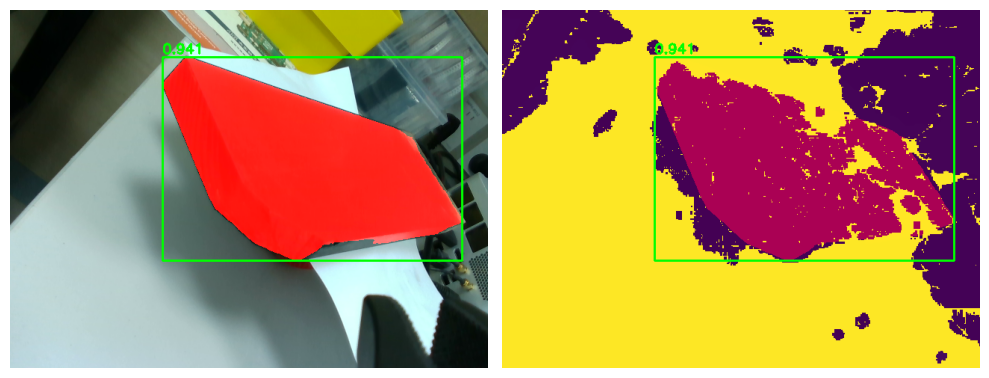

最近点深度： 0.194
单帧原始点云数量: 54631 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 19311
(4, 4) (4, 19311)
Processing image: 9.png


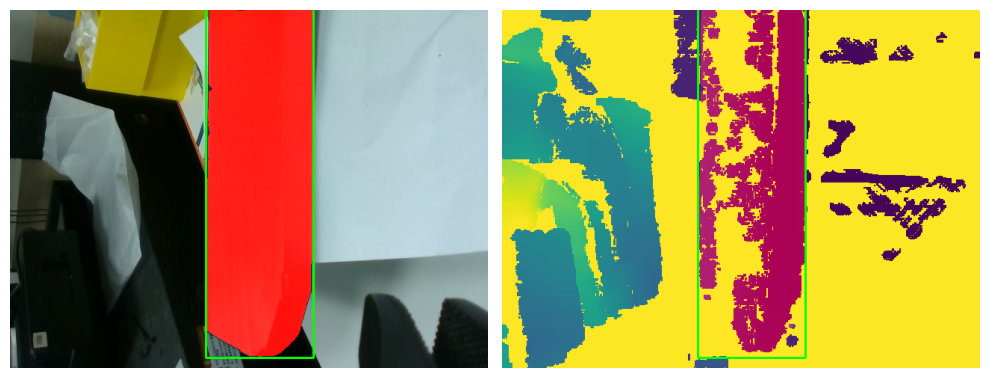

最近点深度： 0.252
单帧原始点云数量: 39807 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 12279
(4, 4) (4, 12279)
Processing image: 8.png


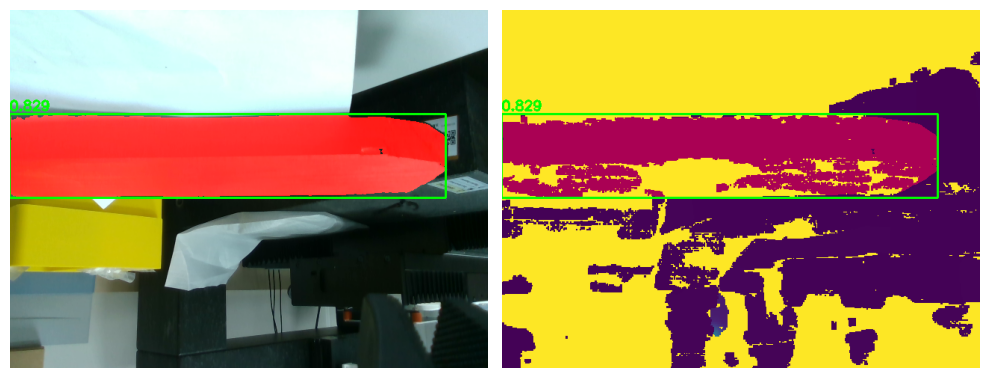

最近点深度： 0.224
单帧原始点云数量: 46488 
 
Remove statistical outliers: [========================================] 100%
Remove statistical outliers: [=======================================>] 97%
 单帧过滤后点云数量: 11438
(4, 4) (4, 11438)


In [2]:
from scipy.spatial.transform import Rotation as R
import os, torch, gc, json, cv2, sys
sys.path.append('/public/home/rastus/AAM')
import open3d as o3d
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from AI_models.LLM_funcitons import positioning
import pandas as pd

def load_camera_config(camera_config_path):
    config = np.load(camera_config_path, allow_pickle=True).item()
    depth_intrinsic = config['depth_intrinsic']
    color_intrinsic = config['color_intrinsic']
    depth_scale = config['depth_scale']
    depth_to_color_extrinsic = config['depth_to_color_extrinsic']

    return color_intrinsic, depth_intrinsic, depth_to_color_extrinsic, depth_scale

def mask_visualization(image_path, depth_path, mask, box, score):
    # 1. 加载RGB
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # 2. 加载深度图 & 转伪彩色
    depth = np.nan_to_num(np.load(depth_path), nan=0.0, posinf=0.0, neginf=0.0)
    valid = depth[depth > 0]
    if len(valid) == 0: valid = [0, 1]  # 防空数组报错保底
    d_min, d_max = valid.min(), valid.max()
    d_range = d_max - d_min if d_max != d_min else 1.0

    depth_col = cv2.applyColorMap(np.clip((depth - d_min) / d_range * 255, 0, 255).astype(np.uint8), cv2.COLORMAP_VIRIDIS)
    depth_col = cv2.cvtColor(depth_col, cv2.COLOR_BGR2RGB)

    # 3. 创建Mask高亮层（仅mask区域有颜色，其余全0）
    mask_2d = np.squeeze(np.array(mask)) > 0
    highlight = np.zeros_like(img)
    highlight[mask_2d] = [255, 0, 0]  # 红色

    # 4. 透明叠加：addWeighted 会自动让非mask区域保持原图
    rgb_out = cv2.addWeighted(img, 1.0, highlight, 1, 0)
    depth_out = cv2.addWeighted(depth_col, 1.0, highlight, 0.4, 0)

    # 5. 绘制单框 + 分数
    x1, y1, x2, y2 = [int(v) for v in box[0]]
    for out in [rgb_out, depth_out]:
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, f"{score[0]:.3f}", (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    # 6. 显示
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1); plt.imshow(rgb_out); plt.axis('off')
    plt.subplot(1, 2, 2); plt.imshow(depth_out); plt.axis('off')
    plt.tight_layout(); plt.show()
    return
    
def end_to_base_transformationMatrix(endpose_path):
    with open(endpose_path, 'r', encoding='utf-8') as f:
        endpose = json.load(f)
    x = float(endpose[0]['x']) /1000000
    y = float(endpose[1]['y']) /1000000
    z = float(endpose[2]['z']) /1000000
    rx = float(endpose[3]['rx']) /1000
    ry = float(endpose[4]['ry']) /1000
    rz = float(endpose[5]['rz']) /1000
    rot = R.from_euler('xyz', [rx, ry, rz], degrees=True)
    beT_rot = rot.as_matrix() 
    beT = np.eye(4)
    beT[:3, :3] = beT_rot
    beT[:3, 3] = [x, y, z]
    
    return beT

def frame_pointcloud_generation(image_path,depth_path,endpose_path, config_path, ecT):
    depth = np.load(depth_path)
    img = cv2.imread(image_path)
    color_intrinsic,_,_,_ = load_camera_config(config_path)
    fx = color_intrinsic['fx']
    fy = color_intrinsic['fy']
    cx = color_intrinsic['ppx']
    cy = color_intrinsic['ppy']

    depth_scale = 1000.0
    mask, box, score = positioning(image_path,'a black object ')
    if len(mask) < 1:
        return [], np.array([])
    else:
        if len(score) > 1:
                max_score_idx = np.argmax(score)
                box = [box[max_score_idx]]
                mask = [mask[max_score_idx]]
                score = [score[max_score_idx]]  
    
        mask_visualization(image_path, depth_path, mask, box, score)
        mask = mask[0][0]
        # 确保深度图是 float32 并转换为米
        if depth.dtype == np.uint16:
            depth = depth.astype(np.float32) / depth_scale
        elif depth.dtype == np.uint8:
            depth = depth.astype(np.float32) * 0.01  # 假设是 0-255 -> 0-2.55m
    
        # 创建网格坐标 (u, v)
        H, W = depth.shape
        v_coords, u_coords = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
    
        # 提取有效点的像素坐标和深度值
        min_depth, max_depth = 0.1, 0.8  
        depth_valid = (depth > min_depth) & (depth < max_depth)
        valid_mask = mask & depth_valid
        u_valid = u_coords[valid_mask]
        v_valid = v_coords[valid_mask]
        d_valid = depth[valid_mask]
        print('最近点深度：',np.min(d_valid))
    
        # 反投影到相机坐标系 (X, Y, Z)
        # 公式: X = (u - cx) * Z / fx, Y = (v - cy) * Z / fy, Z = d
        # fx, fy 是相机内参
        Z_cam = d_valid
        X_cam = (u_valid - cx) * Z_cam / fx
        Y_cam = (v_valid - cy) * Z_cam / fy
        points_cam = np.stack([X_cam, Y_cam, Z_cam], axis=1)  # shape: (N, 3)
    
        print(f"单帧原始点云数量: {points_cam.shape[0]} \n ")
    
        # 创建点云对象
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(points_cam)
    
        if 'img' in locals() and 'v_valid' in locals():
            colors = img[v_valid, u_valid] / 255.0
            pcd.colors = o3d.utility.Vector3dVector(colors)
        
        # 体素化降采样
        pcd = pcd.voxel_down_sample(voxel_size=0.001)
        # 统计滤波（杯子场景优化参数）
        cl, ind = pcd.remove_statistical_outlier(
            nb_neighbors=50,      # 检查 个邻居
            std_ratio=1.0,        #  倍标准差阈值
            print_progress=True)
        # 获取过滤结果
        inlier_cloud = pcd.select_by_index(ind)
        cl, ind = inlier_cloud.remove_radius_outlier(
                nb_points=50,
                radius=0.015)
    
        points_cam = np.asarray(cl.points)
        print('\n 单帧过滤后点云数量:',points_cam.shape[0])
        points_cam = np.column_stack([points_cam, np.ones(len(points_cam))])
        
        beT = end_to_base_transformationMatrix(endpose_path)
        bcT = beT @ ecT
        print(bcT.shape, (points_cam.T).shape )
        points_base = bcT @points_cam.T
        points_base = points_base.T
    
        return points_base, bcT

def visualize_points(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)  # points 是 Nx3 的 numpy 数组
    o3d.visualization.draw_geometries([pcd])
    return


torch.cuda.empty_cache()
gc.collect()
folder_path = Path(r"/public/home/rastus/AAM/construction/data/frame_result/depression_defect")
png_files = list(folder_path.glob('*.png'))
png_names = [p.stem for p in png_files] # p.name 仅获取文件名，不含路径
points_collection = []
bcT_collection = []
print(png_names)

ecT = np.array([[0,0.9397,0.342,-0.0737],
    [-1,0,0,0.044],
    [0,-0.342,0.9397,0.0493],
    [0,0,0,1]], dtype=np.float64)

for name in png_names:
    print(f'Processing image: {name}.png')
    image_path =   str(folder_path) + '/'+ name + '.png'
    depth_path =   str(folder_path) + '/'+ name + '.npy'
    endpose_path = str(folder_path) + '/'+ name + '.json'
    config_path =  '/public/home/rastus/AAM'+ '/perception/result/1st_capturing/camera_config.npy'  # os.getcwd()
    points, bcT = frame_pointcloud_generation(image_path,depth_path,endpose_path, config_path, ecT)
    if len(points) == 0:
        print(f'fail to extract points from image {name}')
        continue
    else:
        points_collection.append(points)
        bcT_collection.append(bcT)

data = {
    'points_collection':points_collection,
    'bcT_collection':bcT_collection
}

with open ('png_sequence.json','w', encoding='utf-8') as f:
    json.dump(png_names,f)
np.save('frame_point_result.npz', data )

# 保存为CSV文件
# df.to_csv('/public/home/rastus/AAM/construction/data/frame_result/frame_points.csv', index=False)

### 刚性变换配准结果

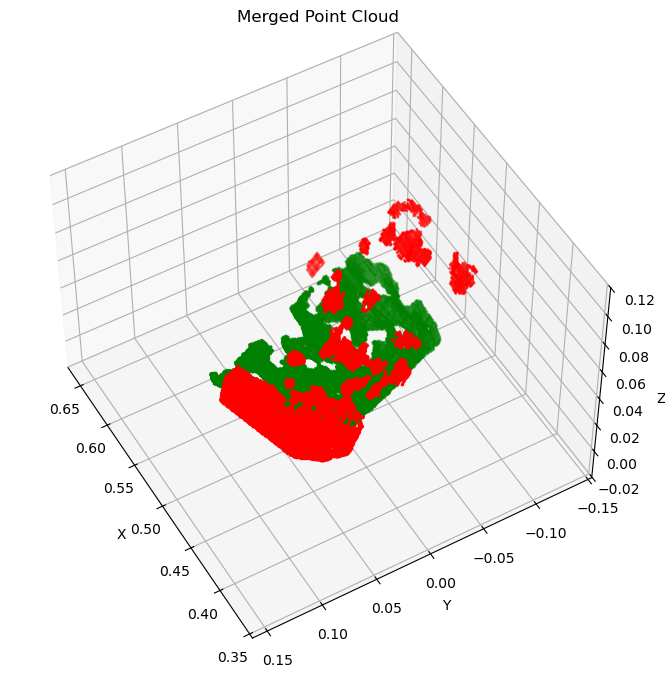

In [11]:
from mpl_toolkits.mplot3d import Axes3D
def visualize_raw_registration_metplotlib(points_collection):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    ax.scatter(points_collection[0][:, 0], points_collection[0][:, 1], points_collection[0][:, 2], s=1, c = 'green')    
    ax.scatter(points_collection[1][:, 0], points_collection[1][:, 1], points_collection[1][:, 2], s=1, c = 'red')  # s=1 for small points
    #ax.scatter(points_collection[2][:, 0], points_collection[2][:, 1], points_collection[2][:, 2], s=1, c = 'yellow')
    #ax.scatter(points_collection[3][:, 0], points_collection[3][:, 1], points_collection[3][:, 2], s=1, c = 'blue')  
    #ax.scatter(points_collection[4][:, 0], points_collection[4][:, 1], points_collection[4][:, 2], s=1, c = 'grey') 
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title('Merged Point Cloud')
    ax.view_init(elev=50, azim=150)
    plt.show()
    return
visualize_raw_registration_metplotlib(points_collection)

### ICP配准结果

In [7]:
import open3d as o3d
import numpy as np
import copy
def draw_registration_result_matplotlib(source, target, transformation, title = "ICP result", elev = 60, azim = 50 ):
    source_temp = copy.deepcopy(source)
    target_temp = copy.deepcopy(target)
    source_temp.transform(transformation)

    target_points = np.asarray(target_temp.points)
    source_points = np.asarray(source_temp.points)
    
    ## 可视化
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    target_colors = target_points[:, 2]
    ax.scatter(target_points[:, 0], target_points[:, 1], target_points[:, 2], s=1, c = target_colors, cmap='viridis')  # s=1 for small points
    #ax.scatter(source_points[:, 0], source_points[:, 1], source_points[:, 2], s=1,cmap='viridis')  

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.title(title)
    ax.view_init(elev, azim)
    plt.show()
    

#### point2plane ICP

RegistrationResult with fitness=6.633780e-01, inlier_rmse=2.944298e-03, and correspondence_set size of 5648
Access transformation to get result.
Transformation is:
[[ 8.75250540e-01 -4.79480716e-01 -6.35195615e-02  1.07059213e-01]
 [ 4.80435909e-01  8.77029797e-01 -2.68980351e-04 -1.75691540e-01]
 [ 5.58375190e-02 -3.02816531e-02  9.97980557e-01 -2.70354944e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


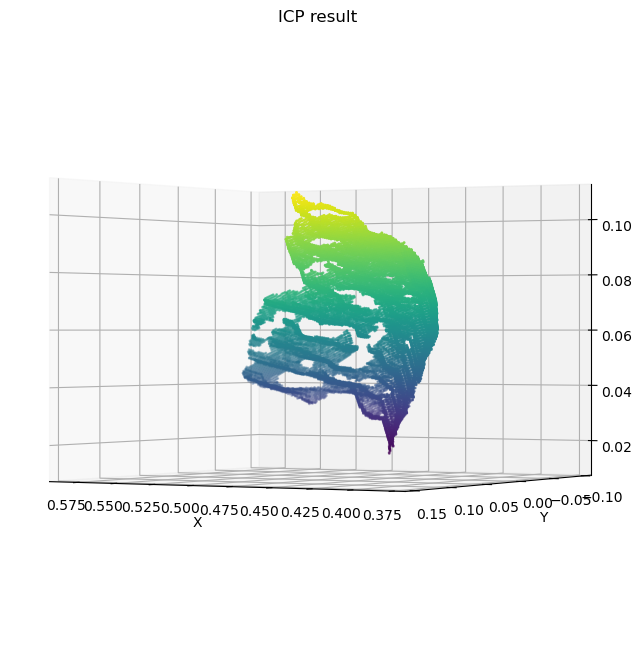

In [10]:
# source
source = o3d.geometry.PointCloud()
source.points = o3d.utility.Vector3dVector(points_collection[1][:, :3])
bc2T = bcT_collection[1]

# target
target = o3d.geometry.PointCloud()
target.points = o3d.utility.Vector3dVector(points_collection[0][:, :3])
bc4T = bcT_collection[0]

threshold = 0.01
trans_init = np.eye(4)
source.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10, max_nn=30))
target.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10, max_nn=30))
reg_p2l = o3d.pipelines.registration.registration_icp(
    source, target, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPlane())
print(reg_p2l)
print("Transformation is:")
print(reg_p2l.transformation)
draw_registration_result_matplotlib(source, target, reg_p2l.transformation, elev=0, azim=120)

In [9]:
# save fused pcd file
source_temp = copy.deepcopy(source)
target_temp = copy.deepcopy(target)
source_temp.transform(reg_p2l.transformation)
fused_pcd = source_temp + target_temp
fused_pcd = fused_pcd.voxel_down_sample(voxel_size=0.001)
#o3d.io.write_point_cloud(os.getcwd()+"/data/completion_result/fused.pcd", fused_pcd)

#### 多帧结果

RegistrationResult with fitness=9.364093e-01, inlier_rmse=2.881314e-03, and correspondence_set size of 18083
Access transformation to get result.
Transformation is:
[[ 0.98429721 -0.17472444  0.02510716  0.02491599]
 [ 0.17511873  0.9844412  -0.01445544 -0.0699957 ]
 [-0.02219081  0.01862519  0.99958025 -0.01015168]
 [ 0.          0.          0.          1.        ]]


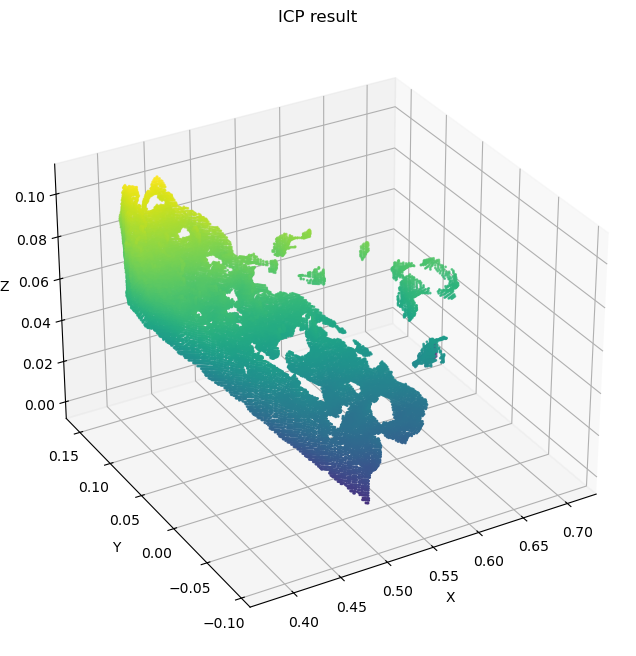

In [18]:
source2 = o3d.geometry.PointCloud()
source2.points = o3d.utility.Vector3dVector(points_collection[2][:, :3])
bc2T = bcT_collection[2]
target2 = o3d.geometry.PointCloud()
target2.points = o3d.utility.Vector3dVector(np.asarray(fused_pcd.points)[:, :3])
bc4T = np.eye(4)

source2.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10, max_nn=30))
target2.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=10, max_nn=30))
reg_p2l = o3d.pipelines.registration.registration_icp(
    source2, target2, threshold, trans_init,
    o3d.pipelines.registration.TransformationEstimationPointToPlane())
print(reg_p2l)
print("Transformation is:")
print(reg_p2l.transformation)
draw_registration_result_matplotlib(source2, target2, reg_p2l.transformation, elev=30, azim=-120)

source2_temp = copy.deepcopy(source2)
target2_temp = copy.deepcopy(target2)
source2_temp.transform(reg_p2l.transformation)
fused_pcd2 = source2_temp + target2_temp
fused_pcd2 = fused_pcd2.voxel_down_sample(voxel_size=0.001)
#o3d.io.write_point_cloud(os.getcwd()+"/result/fused2.pcd", fused_pcd2)
